# Análisis del Mercado Laboral - Data Analyst

## Objetivo

Este notebook analiza ofertas de trabajo reales para el rol de **Data Analyst** con el objetivo de responder preguntas concretas sobre el mercado laboral: ¿qué skills se piden?, ¿cuánta experiencia requieren?, ¿cómo varía por país?

## Fuentes de datos

| Fuente | Método | Países | Registros |
|--------|--------|--------|-----------|
| Adzuna API | API REST | US, GB, AU, CA, BR, MX | 1626 |
| Computrabajo | Web scraping | AR | 62 |

**Total: 1688 ofertas recolectadas entre mayo y junio de 2026.**

## Limitaciones conocidas

- La API gratuita de Adzuna trunca las descripciones a 500 caracteres, lo que subestima la detección de skills técnicas en el cuerpo de las ofertas.
- Computrabajo no devuelve descripción en el scraping, sus 62 registros quedan fuera de algunas secciones.
- La modalidad laboral tiene 98% de nulos, insuficiente para análisis.

## Estructura del notebook

- **Sección 1:** Exploración inicial; shape, nulos, distribuciones
- **Sección 2:** Limpieza y normalización
- **Sección 3:** Análisis y visualizaciones
- **Sección 4:** Exportación

> **Nota:** 
* los insights de este notebook reflejan los datos recolectados entre mayo y junio de 2026. Una nueva ejecución del pipeline generará un dataset diferente y los resultados pueden variar.
- La API gratuita de Adzuna trunca las descripciones a 500 caracteres, lo que limita la detección de skills. Los porcentajes mostrados subestiman la demanda real y deben interpretarse como tendencias orientativas, no como estadísticas representativas.

In [218]:
# Importo las librerías

import requests
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
from pathlib import Path

# Configuración de estilo para los gráficos
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.figsize": (10, 5),
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

In [219]:
DB_PATH = Path("../data/jobs.db") # Ruta al archivo de la base de datos "jobs.db"
conn = sqlite3.connect(DB_PATH) # Conecto a la base de datos "jobs.db"

df = pd.read_sql("SELECT * FROM jobs", conn) # Selecciono todos los datos de la tabla "jobs" y los guardo en un DataFrame

---
## Sección 1: Exploración inicial

In [220]:
# Vista previa de 5 filas aleatorias del DataFrame
df.sample(5)

,id,title,company,location,country,modality,salary_raw,description,date_raw,source,created_at
1320,1321,Data Analyst,Kanshe Infotech,"Mount Rainier, Prince George's County",us,NaN,67698.73,Job Titl e: Data Analyst. Location: Washington...,2026-06-03T12:07:33Z,adzuna,2026-06-03 20:09:40
393,394,Data & Performance Analyst (Sydney/Melbourne/B...,JMC Pty,"The Rocks, Sydney",au,NaN,NaN,JMC Academy is undergoing a significant data a...,2026-05-14T10:32:16Z,adzuna,2026-05-28 19:41:24
735,736,Lead Data Analyst (Marketing Performance),N-iX,Brasil,br,NaN,NaN,Working hours within PST time zone. We're seek...,2026-05-09T18:11:09Z,adzuna,2026-05-28 19:42:05
915,916,Virtual Assistant - Data Analyst,We Clone You,México,mx,NaN,NaN,We Clone You is a leading virtual assistant co...,2026-04-01T10:24:32Z,adzuna,2026-05-28 19:42:25
882,883,Data Analyst,Incode Technologies,México,mx,NaN,NaN,POWER A WORLD OF TRUST Incode is the leading p...,2026-02-27T13:59:19Z,adzuna,2026-05-28 19:42:25


In [221]:
# Dimensiones del dataset: filas y columnas
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

# Tipos de datos y valores nulos por columna
# Primer vistazo para saber qué limpiar y transformar
df.info()

Filas: 1688
Columnas: 11
<class 'pandas.DataFrame'>
RangeIndex: 1688 entries, 0 to 1687
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           1688 non-null   int64
 1   title        1688 non-null   str  
 2   company      1476 non-null   str  
 3   location     1688 non-null   str  
 4   country      1688 non-null   str  
 5   modality     27 non-null     str  
 6   salary_raw   515 non-null    str  
 7   description  1626 non-null   str  
 8   date_raw     1688 non-null   str  
 9   source       1688 non-null   str  
 10  created_at   1688 non-null   str  
dtypes: int64(1), str(10)
memory usage: 145.2 KB


In [222]:
# Porcentaje de valores nulos por columna
print("% de nulos")
print((df.isnull().sum() / len(df)) * 100)

% de nulos
id              0.000000
title           0.000000
company        12.559242
location        0.000000
country         0.000000
modality       98.400474
salary_raw     69.490521
description     3.672986
date_raw        0.000000
source          0.000000
created_at      0.000000
dtype: float64


salary_raw y modality tienen una elevada cantidad de datos nulos

In [223]:
# Distribución de ofertas por país
df["country"].value_counts()

country
br    473
au    281
ca    269
mx    256
gb    185
us    162
ar     62
Name: count, dtype: int64

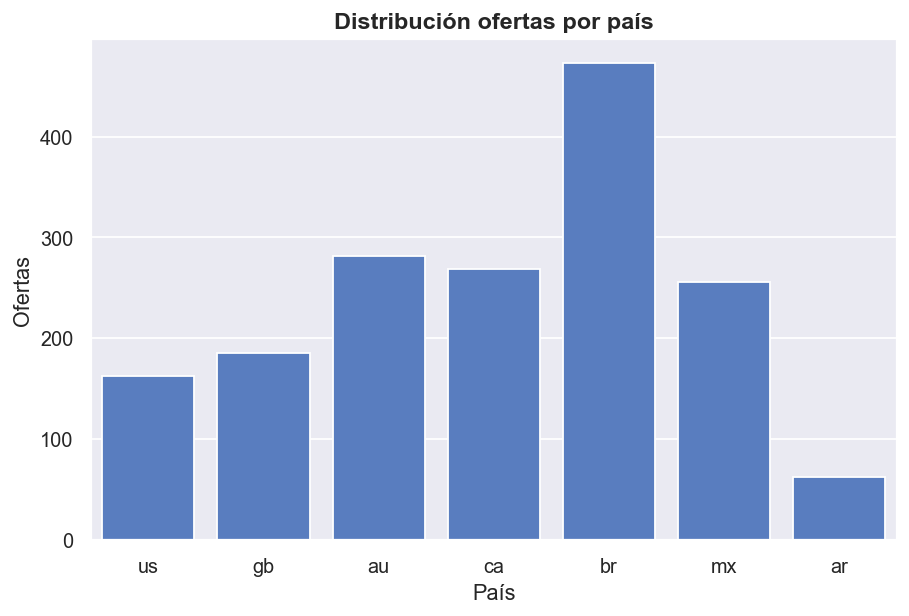

In [224]:
#Visualización de la distribución de ofertas por país
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='country')
plt.title('Distribución ofertas por país')
plt.xlabel('País')
plt.ylabel('Ofertas')
plt.show()

In [225]:
# Distribución de modalidad laboral
# Se esperan muchos nulos ya que Adzuna no provee este dato
df["modality"].value_counts(dropna=False)

modality
NaN                    1661
Presencial y remoto      25
Remoto                    2
Name: count, dtype: int64

Importante señalar que solo se muestran 27 modalidades, ya que el resto son datos nulos.

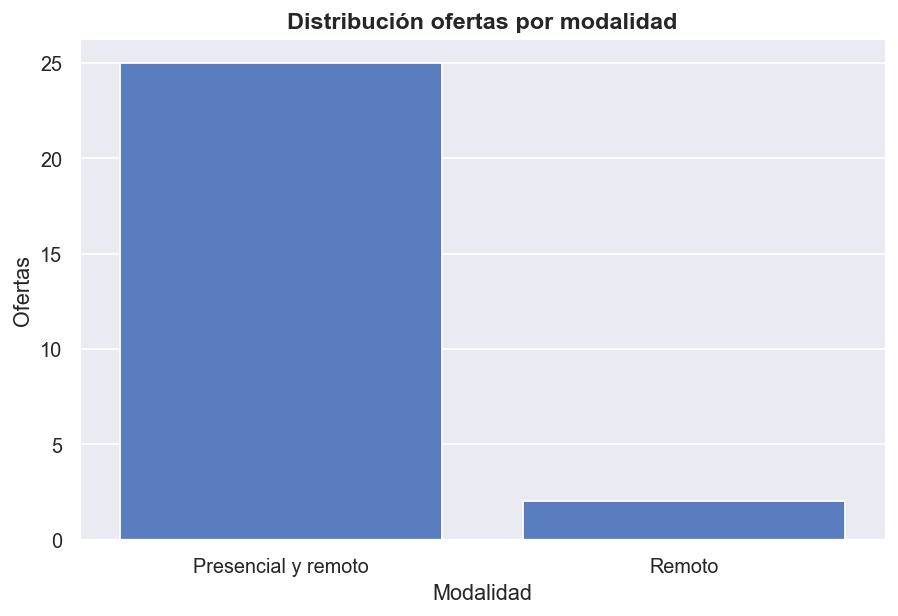

In [226]:
#Visualización de la distribución de modalidad laboral
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='modality')
plt.title('Distribución ofertas por modalidad')
plt.xlabel('Modalidad')
plt.ylabel('Ofertas')
plt.show()

---
## Sección 2: Limpieza y Normalización

In [227]:
# Se crea una copia del dataframe original para no modificar los datos crudos
df_clean = df.copy()

In [228]:
# Elimino espacios en blanco al inicio y al final de los textos
for col in ["title", "company", "location"]:
    df_clean[col] = df_clean[col].str.strip()

In [229]:
# Se rellena company nula con "Unknown" para no perder ofertas
df_clean["company"] = df_clean["company"].fillna("Unknown")

In [230]:
# Convierto date_raw a formato de fecha YYYY-MM-DD
# utc=True porque las fechas de Adzuna están en formato UTC
# errors="coerce" para convertir fechas inválidas a NaT (Not a Time) en lugar de lanzar un error
df_clean["date"] = pd.to_datetime(df_clean["date_raw"], utc=True, errors="coerce").dt.strftime("%Y-%m-%d")

# Verifico que todo esté correcto
df_clean[["company", "date_raw", "date"]].sample(15)

,company,date_raw,date
741,Capgemini,2026-01-20T18:34:26Z,2026-01-20
1066,Uline,2026-05-22T14:47:00Z,2026-05-22
673,Unknown,2026-05-26T18:50:01Z,2026-05-26
1242,Ball Corporation,2026-05-28T17:36:08Z,2026-05-28
391,Newmont,2026-05-19T00:25:12Z,2026-05-19
1435,Pertemps Worcester,2026-06-03T18:56:50Z,2026-06-03
1105,Stefanini,Hace 3 días,NaN
862,Oliver Wyman,2026-05-25T02:36:37Z,2026-05-25
1234,Unknown,2026-05-26T18:49:49Z,2026-05-26
1239,Cadastra,2026-05-28T17:39:16Z,2026-05-28


- Este cambio de fechas es para los datos extraídos de Adzuna, ya que los de Computrabajo no vienen con ningún formato en especial
- Para darles un formato a las fechas extraídas de Computrabajo se va a requerir de un código más complejo y de hacer uso de la librería "re"

In [231]:
# Se verifica el formato de created_at en filas de Computrabajo
df_clean[df_clean["source"] == "computrabajo"][["date_raw", "created_at"]].sample(5)

,date_raw,created_at
1082,Hace 4 días,2026-05-28 19:42:38
1104,Hace 2 días,2026-05-28 19:42:38
1684,Ayer,2026-06-03 20:11:29
1085,20 de mayo,2026-05-28 19:42:38
1072,Hace 18 horas,2026-05-28 19:42:38


created_at es la misma fecha en todos los registros, por lo que se la usara de fecha base para la transformación 

In [232]:
# Se define la función para convertir fechas relativas de Computrabajo a formato YYYY-MM-DD
def parse_date_computrabajo(date_raw: str, created_at: str) -> str:
    """
    Convierte fechas relativas en español de Computrabajo a formato YYYY-MM-DD.
    Usa created_at como fecha de referencia para calcular fechas relativas.
    
    Casos cubiertos:
    - "Hace X días"   → created_at - X días
    - "Hace X horas"  → created_at - X horas (se redondea al día)
    - "Ayer"          → created_at - 1 día
    - "19 de mayo"    → fecha absoluta del año de created_at
    - "Más de 30 días"→ NaT, ya que no logré encontrar una manera de interpretar esta fecha
    """
    # Normalizamos espacios múltiples internos
    # Convertimos a minúsculas para facilitar la comparación
    # Ejemplo: "  Hace   3   días " → "hace 3 días"
    text = re.sub(r"\s+", " ", str(date_raw)).strip().lower()
    
    # Fecha base: cuándo corrió el scraper
    # created_at es la fecha en formato string, lo convertimos a datetime para hacer cálculos
    base = pd.to_datetime(created_at)
    
    # "Ayer"
    # Si el texto es exactamente "ayer", restamos un día a la fecha base
    # Ejemplo: "ayer" → base - 1 día
    if text == "ayer":
        return (base - pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    
    # "Hace X días" o "Hace X horas"
    # Usamos expresiones regulares para extraer el número de días u horas
    # "hace 7 días" → encuentra match, captura "7"
    # "ayer"        → no encuentra match, devuelve None
    # Ejemplo: "hace 3 días" → match_dias.group(1) = "3"
    match_dias = re.search(r"hace (\d+) día", text)
    match_horas = re.search(r"hace (\d+) hora", text)
    
    # Si encontramos "hace X día(s)", restamos X días a la fecha base
    if match_dias:
        n = int(match_dias.group(1))
        return (base - pd.Timedelta(days=n)).strftime("%Y-%m-%d")
    
    # Si encontramos "hace X hora(s)", restamos X horas a la fecha base y redondeamos al día
    if match_horas:
        n = int(match_horas.group(1))
        return (base - pd.Timedelta(hours=n)).strftime("%Y-%m-%d")
    
    # "19 de mayo" → fecha absoluta
    meses = {
        "enero": 1, "febrero": 2, "marzo": 3, "abril": 4,
        "mayo": 5, "junio": 6, "julio": 7, "agosto": 8,
        "septiembre": 9, "octubre": 10, "noviembre": 11, "diciembre": 12
    }
    # Usamos una expresión regular para extraer el día y el mes
    # "19 de mayo" → match_fecha.group(1) = "19", match_fecha.group(2) = "mayo"
    # Ejemplo: "19 de mayo" → base.year-05-19
    match_fecha = re.search(r"(\d+) de (\w+)", text)
    if match_fecha:
        dia = int(match_fecha.group(1))
        mes = meses.get(match_fecha.group(2))
        if mes:
            return f"{base.year}-{mes:02d}-{dia:02d}"
    
    # "Más de 30 días" u otros no reconocidos
    return None

In [233]:
# Aplicamos la función de parseo a las filas de Computrabajo

df_clean["date"] = df_clean.apply(
    lambda row: (
        # Si es Computrabajo, se usa la función de parseo que creamos
        parse_date_computrabajo(row["date_raw"], row["created_at"])
        if row["source"] == "computrabajo"
        # Si es Adzuna, se mantiene el date que ya parseamos antes
        else row["date"]
    ),
    axis=1 # axis=1 significa que aplicamos la función fila por fila
)

# Verifico los resultados en ambas fuentes
df_clean[df_clean["source"] == "computrabajo"][["date_raw", "created_at", "date"]].sample(15)

,date_raw,created_at,date
1110,Hace 7 días,2026-05-28 19:42:38,2026-05-21
1074,Ayer,2026-05-28 19:42:38,2026-05-27
1093,13 de mayo,2026-05-28 19:42:38,2026-05-13
1098,Hace 7 horas,2026-05-28 19:42:38,2026-05-28
1677,Hace 4 horas,2026-06-03 20:11:29,2026-06-03
1682,Hace 5 días,2026-06-03 20:11:29,2026-05-29
1104,Hace 2 días,2026-05-28 19:42:38,2026-05-26
1083,Hace 6 días,2026-05-28 19:42:38,2026-05-22
1685,Hace 2 días,2026-06-03 20:11:29,2026-06-01
1097,Hace 7 días,2026-05-28 19:42:38,2026-05-21


In [234]:
# Reviso el formato de los salarios en computrabajo para ver cómo transformarlos
df_clean[df_clean["source"] == "computrabajo"]["salary_raw"].value_counts(dropna=False)

salary_raw
NaN                                      48
$ 1.000.000,00 (Mensual) + Comisiones     4
$ 1.300.000,00 (Mensual)                  3
$ 1.111.111,00 (Mensual)                  3
$ 111.111,00 (Mensual)                    1
$ 10.000,00 (Mensual)                     1
$ 2.000,00 (Mensual)                      1
$ 11.111,00 (Mensual)                     1
Name: count, dtype: int64

In [235]:
def parse_salary(salary_raw: str, source: str) -> float:
    """
    Convierte salary_raw a float según la fuente.
    
    Adzuna: "62305.64" → 62305.64
    Computrabajo: "$ 1.111.111,00 (Mensual)" → 1111111.0
    Devuelve None si es nulo o no se puede convertir.
    """
    if pd.isna(salary_raw):
        return None
    
    # ============
    # PARA ADZUNA
    # ============
    # adzuna ya tiene el salario en formato numérico como string, solo hay que convertirlo a float
    if source == "adzuna":
        try:
            return float(salary_raw)
        except ValueError:
            return None
    # ==================
    # PARA COMPUTRABAJO
    # ==================
    # computrabajo tiene el salario con formato de texto, con símbolos de moneda, puntos como separadores de miles y comas como decimales, además de texto adicional como "(Mensual)"
    if source == "computrabajo":
        # Elimina todo excepto dígitos, puntos y comas
        cleaned = re.sub(r"[^\d.,]", "", salary_raw) # [^\d.,] significa dígitos, puntos y comas, el ^ dentro de los corchetes niega el conjunto, por lo que se eliminan todos los caracteres que no sean dígitos, puntos o comas
        # Formato argentino: punto como separador de miles, coma como decimal
        # "1.111.111,00" → "1111111.00"
        cleaned = cleaned.replace(".", "").replace(",", ".")
        try:
            return float(cleaned)
        except ValueError:
            return None

# Aplica la función fila por fila
df_clean["salary_clean"] = df_clean.apply(
    lambda row: parse_salary(row["salary_raw"], row["source"]), # Llama a parse_salary con los valores de salary_raw y source de cada fila
    axis=1
)

# Verificamos
print(df_clean[["salary_raw", "salary_clean", "source"]].dropna(subset=["salary_raw"]).sample(10))
print("=" * 40)
print(df_clean[df_clean["source"] == "computrabajo"]["salary_clean"].value_counts(dropna=False))

     salary_raw  salary_clean  source
977           1          1.00  adzuna
1355   78147.82      78147.82  adzuna
108      104000     104000.00  adzuna
988      336000     336000.00  adzuna
1415      55000      55000.00  adzuna
1318  127952.91     127952.91  adzuna
1359   95796.48      95796.48  adzuna
422       87000      87000.00  adzuna
2      84199.34      84199.34  adzuna
1464      83554      83554.00  adzuna
salary_clean
NaN          48
1000000.0     4
1300000.0     3
1111111.0     3
111111.0      1
10000.0       1
2000.0        1
11111.0       1
Name: count, dtype: int64


In [236]:
# Estadísticas descriptivas de salary_clean por país para confirmar de que cada uno está en su moneda local
print(df_clean.groupby("country")["salary_clean"].agg(["count", "median", "mean"]).round(2))

         count      median       mean
country                              
ar          14  1000000.00  811968.21
au          30   114641.00  103244.13
br          17       12.00    5356.59
ca          75    75000.00   68709.36
gb         181    44444.73   50276.39
mx          36   192000.00  162621.97
us         162    94784.54   97905.29


In [237]:
# Muestra ejemplos de salary_raw por país para ver si están puestos como mensual o anual

print("--- AR sample salary_raw ---")
print(df_clean[df_clean["country"] == "ar"]["salary_raw"].dropna().head(10).tolist())

print("\n--- AU sample salary_raw ---")
print(df_clean[df_clean["country"] == "au"]["salary_raw"].dropna().head(10).tolist())

print("\n--- BR sample salary_raw ---")
print(df_clean[df_clean["country"] == "br"]["salary_raw"].dropna().head(10).tolist())

print("\n--- CA sample salary_raw ---")
print(df_clean[df_clean["country"] == "ca"]["salary_raw"].dropna().head(10).tolist())

print("\n--- GB sample salary_raw ---")
print(df_clean[df_clean["country"] == "gb"]["salary_raw"].dropna().head(10).tolist())

print("\n--- MX sample salary_raw ---")
print(df_clean[df_clean["country"] == "mx"]["salary_raw"].dropna().head(10).tolist())

print("\n--- US sample salary_raw ---")
print(df_clean[df_clean["country"] == "us"]["salary_raw"].dropna().head(5).tolist())

--- AR sample salary_raw ---
['$ 111.111,00 (Mensual)', '$ 1.300.000,00 (Mensual)', '$ 1.111.111,00 (Mensual)', '$ 10.000,00 (Mensual)', '$ 1.111.111,00 (Mensual)', '$ 2.000,00 (Mensual)', '$ 11.111,00 (Mensual)', '$ 1.111.111,00 (Mensual)', '$ 1.000.000,00 (Mensual) + Comisiones', '$ 1.000.000,00 (Mensual) + Comisiones']

--- AU sample salary_raw ---
['156000', '75000', '115000', '115000', '125000', '95000', '930', '140000', '125340', '114251']

--- BR sample salary_raw ---
['360', '18000', '24', '12', '12', '12', '330', '12', '12', '12']

--- CA sample salary_raw ---
['110000', '62400', '75000', '79650', '70000', '55000', '97020', '87000', '74000', '56000']

--- GB sample salary_raw ---
['30000', '25000', '25000', '25000', '25000', '38000', '40000', '93600', '50967.69', '52000']

--- MX sample salary_raw ---
['25200', '300000', '24000', '36000', '1', '228000', '204000', '30000', '300000', '1']

--- US sample salary_raw ---
['62305.64', '94013.06', '84199.34', '185207.56', '115211.6']

* Los salarios de Adzuna están expresados como sueldos anuales.
* Los salarios de computrabajo son todos mensuales.

In [238]:
# ============================================================
# NORMALIZACIÓN SALARIAL
# Objetivo: convertir todos los salarios a USD mensual
# para poder comparar entre países
# ============================================================

# Paso 1: Obtener tipos de cambio actualizados
# open.er-api.com es gratuito, sin API key y sin registro
# Devuelve cuántas unidades de cada moneda equivalen a 1 USD
# Ejemplo: "ARS": 1426.97 significa que 1 USD = 1426.97 ARS
def get_exchange_rates():
    url = "https://open.er-api.com/v6/latest/USD"
    response = requests.get(url)
    if response.status_code == 200: # 200 significa que la solicitud fue exitosa
        data = response.json() # Convierte la respuesta JSON a un diccionario de Python
        rates = data["rates"] # Extrae el diccionario de tasas de cambio
        rates["USD"] = 1.0  # agregamos USD manualmente porque es la base
        return rates
    else:
        print(f"Error al obtener tipos de cambio: {response.status_code}")
        return None

rates = get_exchange_rates()
print(rates)

# Paso 2: Mapeo de país a moneda local
COUNTRY_CURRENCY = {
    "us": "USD",
    "gb": "GBP",
    "au": "AUD",
    "ca": "CAD",
    "ar": "ARS",
    "mx": "MXN",
    "br": "BRL",
}

# Paso 3: Unidad de salary_clean por país
# AR → mensual (confirmado, lo dice explícitamente en salary_raw)
# Resto → anual (valores de Adzuna)
SALARY_UNIT = {
    "us": "annual",
    "gb": "annual",
    "au": "annual",
    "ca": "annual",
    "ar": "monthly",
    "mx": "annual",
    "br": "annual",
}

def convert_to_usd(salary, country, rates):
    """
    Convierte un salario en moneda local a USD.
    
    Argumentos:
        salary: valor numérico del salario en moneda local
        country: código de país
        rates: diccionario de tipos de cambio (1 USD = X moneda local)
    
    Returns:
        float: salario en USD, o None si no hay dato válido
    """
    
    currency = COUNTRY_CURRENCY[country]
    
    # USD ya está en la moneda correcta, no hace falta convertir
    if currency == "USD":
        return round(salary, 2)
    
    # Dividimos por el tipo de cambio para obtener el equivalente en USD
    # Ejemplo: 1.300.000 ARS / 1426.97 = 911 USD
    rate = rates.get(currency) # obtenemos el tipo de cambio para la moneda del país
    if not rate:
        return None
    
    return round(salary / rate, 2)

def to_monthly_usd(salary_usd, country):
    """
    Convierte salary_usd a mensual según la unidad inferida por país.
    Los salarios anuales se dividen por 12.
    
    Argumentos:
        salary_usd: salario ya convertido a USD
        country: código de país
    
    Returns:
        float: salario mensual en USD, o None si no hay dato válido
    """
    if pd.isna(salary_usd) or country not in SALARY_UNIT:
        return None
    
    if SALARY_UNIT[country] == "annual":
        return round(salary_usd / 12, 2)
    else:
        # AR ya está en mensual, no hace falta dividir
        return round(salary_usd, 2)

# Paso 4: Aplicamos las conversiones directamente sobre df_clean
# Primero convertimos a USD según el tipo de cambio
df_clean["salary_usd"] = df_clean.apply(
    lambda row: convert_to_usd(row["salary_clean"], row["country"], rates),
    axis=1
)

# Luego estandarizamos a mensual según la unidad de cada país
df_clean["salary_monthly_usd"] = df_clean.apply(
    lambda row: to_monthly_usd(row["salary_usd"], row["country"]),
    axis=1
)

# Paso 5: Filtramos valores inválidos directamente en df_clean
# Criterio: salario mensual en USD mayor a 200
# Esto elimina placeholders (valor 1), errores de scraping (valor 12)
# y salarios claramente incorrectos
# Las filas sin dato de salario (NaN) se conservan, no las eliminamos
df_clean.loc[
    df_clean["salary_monthly_usd"].notna() & 
    (df_clean["salary_monthly_usd"] <= 200),
    "salary_monthly_usd"
] = None

# Verificamos el resultado
print(df_clean.groupby("country")["salary_monthly_usd"].agg(["count", "median", "mean"]).round(2))

{'USD': 1.0, 'AED': 3.6725, 'AFN': 63.248185, 'ALL': 82.00019, 'AMD': 368.38674, 'ANG': 1.79, 'AOA': 924.195588, 'ARS': 1435.3812, 'AUD': 1.400576, 'AWG': 1.79, 'AZN': 1.698864, 'BAM': 1.685146, 'BBD': 2, 'BDT': 122.702961, 'BGN': 1.685146, 'BHD': 0.376, 'BIF': 2979.199814, 'BMD': 1, 'BND': 1.282773, 'BOB': 6.919206, 'BRL': 5.030038, 'BSD': 1, 'BTN': 95.7907, 'BWP': 13.648329, 'BYN': 2.799693, 'BZD': 2, 'CAD': 1.388043, 'CDF': 2276.177231, 'CHF': 0.790956, 'CLF': 0.022484, 'CLP': 888.713176, 'CNH': 6.774119, 'CNY': 6.788285, 'COP': 3574.935432, 'CRC': 456.860847, 'CUP': 24, 'CVE': 95.00449, 'CZK': 20.846012, 'DJF': 177.721, 'DKK': 6.429542, 'DOP': 58.129, 'DZD': 133.226929, 'EGP': 51.943706, 'ERN': 15, 'ETB': 159.896982, 'EUR': 0.861602, 'FJD': 2.194561, 'FKP': 0.744598, 'FOK': 6.430042, 'GBP': 0.744599, 'GEL': 2.661475, 'GGP': 0.744598, 'GHS': 11.787333, 'GIP': 0.744598, 'GMD': 74.169501, 'GNF': 8757.532427, 'GTQ': 7.618698, 'GYD': 208.946866, 'HKD': 7.836895, 'HNL': 26.583362, 'HRK':

In [239]:
print(df_clean.columns.tolist())

['id', 'title', 'company', 'location', 'country', 'modality', 'salary_raw', 'description', 'date_raw', 'source', 'created_at', 'date', 'salary_clean', 'salary_usd', 'salary_monthly_usd']


In [240]:
# Eliminamos columnas que ya no necesitamos
# salary_raw y date_raw → columnas originales, ya procesadas
# salary_clean y salary_usd → pasos intermedios de la conversión
# modality → 98% nulos, insuficiente para análisis
# solamente dejo las que considero importantes para la base de datos final
df_clean = df_clean.drop(columns=["modality", "salary_raw", "date_raw", "salary_clean", "salary_usd"])

print(df_clean.columns.tolist())
print(df_clean.shape)

['id', 'title', 'company', 'location', 'country', 'description', 'source', 'created_at', 'date', 'salary_monthly_usd']
(1688, 10)


In [241]:
# Revisamos que todo esté correcto
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1688 entries, 0 to 1687
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1688 non-null   int64  
 1   title               1688 non-null   str    
 2   company             1688 non-null   str    
 3   location            1688 non-null   str    
 4   country             1688 non-null   str    
 5   description         1626 non-null   str    
 6   source              1688 non-null   str    
 7   created_at          1688 non-null   str    
 8   date                1687 non-null   str    
 9   salary_monthly_usd  476 non-null    float64
dtypes: float64(1), int64(1), str(8)
memory usage: 132.0 KB


In [242]:
# Guardo jobs_clean en la base de datos como tabla "jobs_clean" 
df_clean.to_sql("jobs_clean", conn, if_exists="replace", index=False)
print(f"Tabla jobs_clean guardada: {len(df_clean)} filas")

Tabla jobs_clean guardada: 1688 filas


---
## Sección 3: Análisis y Gráficos

In [243]:
# Llamo solo a las columnas que voy a necesitar para el análisis y visualización para manejarme con un dataframe más liviano y evitar confusiones con columnas que ya no necesito. 

query = "SELECT title, country, description, source, date, salary_monthly_usd FROM jobs_clean"

df_clean = pd.read_sql(query, conn)
df_clean

,title,country,description,source,date,salary_monthly_usd
0,Data Analyst - Data Analyst I,us,Job: 3033642 Job Description: Data Analyst - D...,adzuna,2026-05-07,5192.14
1,Data Analyst,us,Job Description 45-50/hr Insight Global is hir...,adzuna,2026-05-20,7834.42
2,Data Analyst,us,Summary Job title: Data Analyst Job ID: null D...,adzuna,2026-04-16,7016.61
3,Data Analyst,us,"Our client, a leading organization in the indu...",adzuna,2026-05-13,15433.96
4,Data Analyst,us,We have an outstanding Contract position for a...,adzuna,2026-05-19,9600.97
...,...,...,...,...,...,...
1683,Deskside Support Analyst,ar,NaN,computrabajo,2026-06-03,NaN
1684,Analista contable para atención al cliente,ar,NaN,computrabajo,2026-06-02,NaN
1685,Analista de pricing y estrategia comercial,ar,NaN,computrabajo,2026-06-01,NaN
1686,Asesor Comercial de vehículos,ar,NaN,computrabajo,2026-05-29,696.68


---
## 3.1 ¿Cuáles son las skills técnicas demandadas?

In [244]:
# Lista predefinida de skills relevantes para Data Analyst
SKILLS = [
    # Lenguajes de programación
    "python", "r", "scala", "julia",
    # SQL y bases de datos
    "sql", "mysql", "postgresql", "sqlite", "bigquery", "snowflake", "redshift",
    # BI y visualización
    "power bi", "tableau", "looker", "excel", "google sheets", "qlik",
    # Cloud
    "aws", "azure", "gcp", "google cloud",
    # Librerías de Python
    "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", "scipy",
    # Otras herramientas
    "spark", "airflow", "dbt", "git", "github", "jira", "confluence",
    # Conceptos
    "machine learning", "statistics", "data modeling", "etl", "api",
]

# Función para extraer skills de un texto usando expresiones regulares
def extract_skills(text: str, skill_list: list) -> list:
    if not isinstance(text, str):
        return []
    
    text_lower = text.lower()
    found = []
    
    for skill in skill_list:
        # Para evitar falsos positivos, se busca la skill como palabra completa usando \b (boundary) en regex
        # \b marca límite de palabra, no matchea subcadenas
        # re.escape protege caracteres especiales como "." o "+"
        # Ejemplo: para skill "sql", el patrón sería r'\bsql\b', que matchea "sql" pero no "nosql"
        pattern = r'\b' + re.escape(skill) + r'\b'
        if re.search(pattern, text_lower):
            found.append(skill)
    
    return found

# Filtra solo las filas que tienen descripción (las NaN no sriven para NLP)
df_with_desc = df_clean[df_clean["description"].notna()].copy()
# Aplica la función de extracción de skills a la columna de descripción y guarda los resultados en una nueva columna "skills_found"
df_with_desc["skills_found"] = df_with_desc["description"].apply(lambda x: extract_skills(x, SKILLS))

# Contar ocurrencias totales
# Esta línea hace una lista de todas las skills encontradas en todas las descripciones.
all_skills = [skill for skills in df_with_desc["skills_found"] for skill in skills]
# Cuenta cuántas veces aparece cada skill en la lista all_skills, devolviendo un diccionario donde las claves son las skills y los valores son las cantidades.
skill_counts = Counter(all_skills) 

# Crea un DataFrame con las 20 skills más comunes y sus conteos, con columnas "skill" y "count"
df_skills = pd.DataFrame(skill_counts.most_common(20), columns=["skill", "count"])
# Agrega una columna de porcentajes: cuántas ofertas mencionan cada skill
df_skills["%jobs"] = (df_skills["count"] / len(df_with_desc) *100).round(2)

df_skills

,skill,count,%jobs
0,sql,86,5.29
1,power bi,68,4.18
2,excel,39,2.40
3,python,30,1.85
4,r,25,1.54
5,tableau,24,1.48
6,git,23,1.41
7,etl,20,1.23
8,snowflake,19,1.17
9,azure,16,0.98


Que sql, Power BI o Python sean pedidos en máximo 5% de los trabajos es algo atípico, no tiene ningún sentido.

In [245]:
# Veamos una descripción real para entender qué estamos procesando
print(df_with_desc["description"].iloc[0])

Job: 3033642 Job Description: Data Analyst - Data Analyst I Location: Austin, Texas (Onsite) Employment Type: Contract Role Overview This position supports effective decision-making through economic, financial, and market analysis of critical issues. The role involves capacity planning, price and cost modeling, and evaluating returns on investment. The Data Analyst will also assist with capacity forecasting, budgeting, and reporting for operating expenses, capital, and resource allocation, whil…


La descripción se corta a los 500 caracteres...

In [246]:
# Cuántas descripciones son muy cortas o están truncadas
df_with_desc["desc_length"] = df_with_desc["description"].str.len()

print(df_with_desc["desc_length"].describe())
print(f"\nDescripciones con más de 500 caracteres: {(df_with_desc['desc_length'] > 500).sum()}")

count    1626.000000
mean      499.394834
std        11.380808
min       209.000000
25%       500.000000
50%       500.000000
75%       500.000000
max       500.000000
Name: desc_length, dtype: float64

Descripciones con más de 500 caracteres: 0


#### Limitación: descripciones truncadas

El análisis de la longitud de las descripciones revela que **las descripciones tienen un límite de 500 caracteres.** Un corte impuesto por la API gratuita de Adzuna.

Esto explica los porcentajes bajos en el análisis de skills: las habilidades técnicas (SQL, Python, Power BI) suelen aparecer en el cuerpo de la oferta, no en la introducción. Con solo 500 caracteres, es realmente muy difícil poder campurar todo el skill técnico, por lo que las muestras que obtendremos son desfavoradamente bajas.

**Impacto en el análisis:**
- Los porcentajes de skills subestiman la demanda real
- Los rankings relativos entre skills son más válidos
- El análisis es representativo de lo visible en la introducción de cada oferta

**Decisión:** se documenta como limitación y se continúa el análisis con los datos disponibles.

In [247]:
total_con_desc = len(df_with_desc)
total_con_skills = (df_with_desc["skills_found"].apply(len) > 0).sum()

df_skills["pct_total"] = (df_skills["count"] / total_con_desc * 100).round(1)
df_skills["pct_con_skills"] = (df_skills["count"] / total_con_skills * 100).round(1)

print(f"Ofertas con descripción: {total_con_desc}")
print(f"Ofertas donde se detectó al menos una skill: {total_con_skills}")
df_skills

Ofertas con descripción: 1626
Ofertas donde se detectó al menos una skill: 260


,skill,count,%jobs,pct_total,pct_con_skills
0,sql,86,5.29,5.3,33.1
1,power bi,68,4.18,4.2,26.2
2,excel,39,2.40,2.4,15.0
3,python,30,1.85,1.8,11.5
4,r,25,1.54,1.5,9.6
5,tableau,24,1.48,1.5,9.2
6,git,23,1.41,1.4,8.8
7,etl,20,1.23,1.2,7.7
8,snowflake,19,1.17,1.2,7.3
9,azure,16,0.98,1.0,6.2


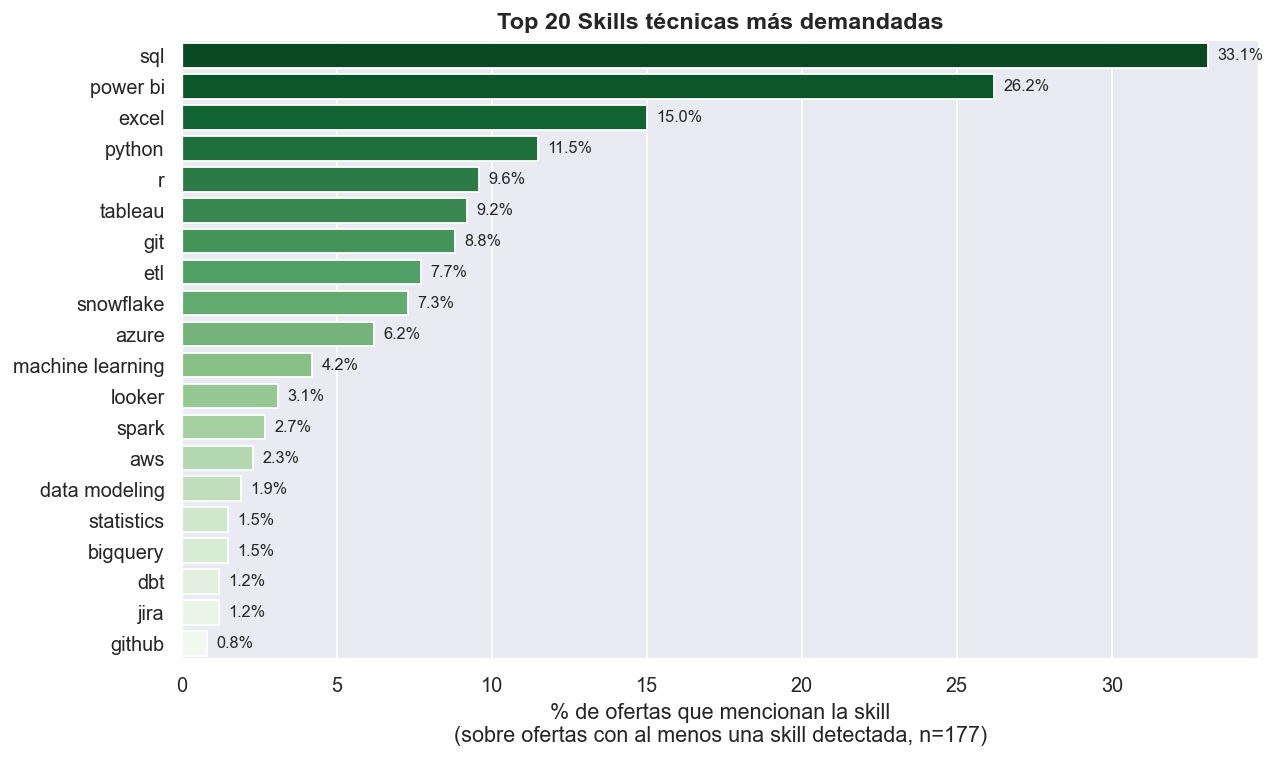

In [248]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_skills,
    x="pct_con_skills",
    y="skill",
    palette="Greens_r",
    hue="skill",
    ax=ax,
)

ax.set_title("Top 20 Skills técnicas más demandadas")
ax.set_xlabel("% de ofertas que mencionan la skill\n(sobre ofertas con al menos una skill detectada, n=177)")
ax.set_ylabel("")

# Etiquetas con el porcentaje al lado de cada barra
for bar, val in zip(ax.patches, df_skills["pct_con_skills"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../dashboard/assets/3_1_skills_demandadas.png", dpi=130)
plt.show()

## Insight 3.1 - Skills técnicas más demandadas

* SQL aparece en 1 de cada 3 ofertas con skills detectables, si tuviera que priorizar una sola herramienta para aprender, sería esta.

* Power BI y Excel siguen siendo muy relevantes. Esperaba ver más Python, pero aparece en solo el 14% de los casos. Puede estar subestimado por el truncado de las descripciones, pero igual es un dato para tener en cuenta.

**Conclusión:** Según esta muestra, las 4 herramientas más usadas en puestos de data analyst son SQL, Power BI, Excel, Python.

---
## 3.2 ¿Cuáles son los requisitos Junior?

In [249]:
# Palabras clave por nivel de seniority
# Buscamos en title y description combinados
JUNIOR_KEYWORDS = ["junior", "entry level", "entry-level", "intern", "trainee", "jr", "jr."]
SENIOR_KEYWORDS = ["senior", "sr.", "sr ", "lead", "lider", "líder", "head of"]

def classify_seniority(row):
    """
    Clasifica una oferta según su nivel de seniority.
    
    Combina el título y la descripción en un solo texto y busca
    palabras clave de cada nivel. Si no encuentra ninguna, devuelve
    "Not Specified".
    
    Argumentos:
        row: una fila del DataFrame (título + descripción)
    
    Returns:
        str: "Junior", "Senior" o "Not Specified"
    """
    
    # Combinamos title y description en un solo texto
    # filter(None, [...]) elimina los valores None antes de unir
    # .lower() convierte todo a minúsculas para que la búsqueda no sea case-sensitive
    text = " ".join(filter(None, [
        str(row.get("title", "")),
        str(row.get("description", "")) if pd.notna(row.get("description")) else ""
    ])).lower()
    
    # Buscamos primero junior. Si matchea, no seguimos evaluando
    if any(kw in text for kw in JUNIOR_KEYWORDS):
        return "Junior"
    # Si no es junior, evaluamos senior
    elif any(kw in text for kw in SENIOR_KEYWORDS):
        return "Senior"
    # Si no matchea ninguno, la oferta no especifica nivel
    else:
        return "Not Specified"

# Aplicamos la función fila por fila sobre todo el DataFrame
# axis=1 indica que la función recibe una fila completa, no una columna
df_clean["seniority"] = df_clean.apply(classify_seniority, axis=1)

# Contamos cuántas ofertas hay por cada categoría
seniority_counts = df_clean["seniority"].value_counts().reset_index() # value_counts devuelve el conteo de cada categoría, reset_index para convertir el índice en una columna normal
seniority_counts.columns = ["seniority", "count"] # Renombramos las columnas para que tengan nombres descriptivos 

# Calculamos el porcentaje sobre el total de ofertas
seniority_counts["pct"] = (seniority_counts["count"] / len(df) * 100).round(2)

seniority_counts

,seniority,count,pct
0,Not Specified,817,48.40
1,Senior,703,41.65
2,Junior,168,9.95


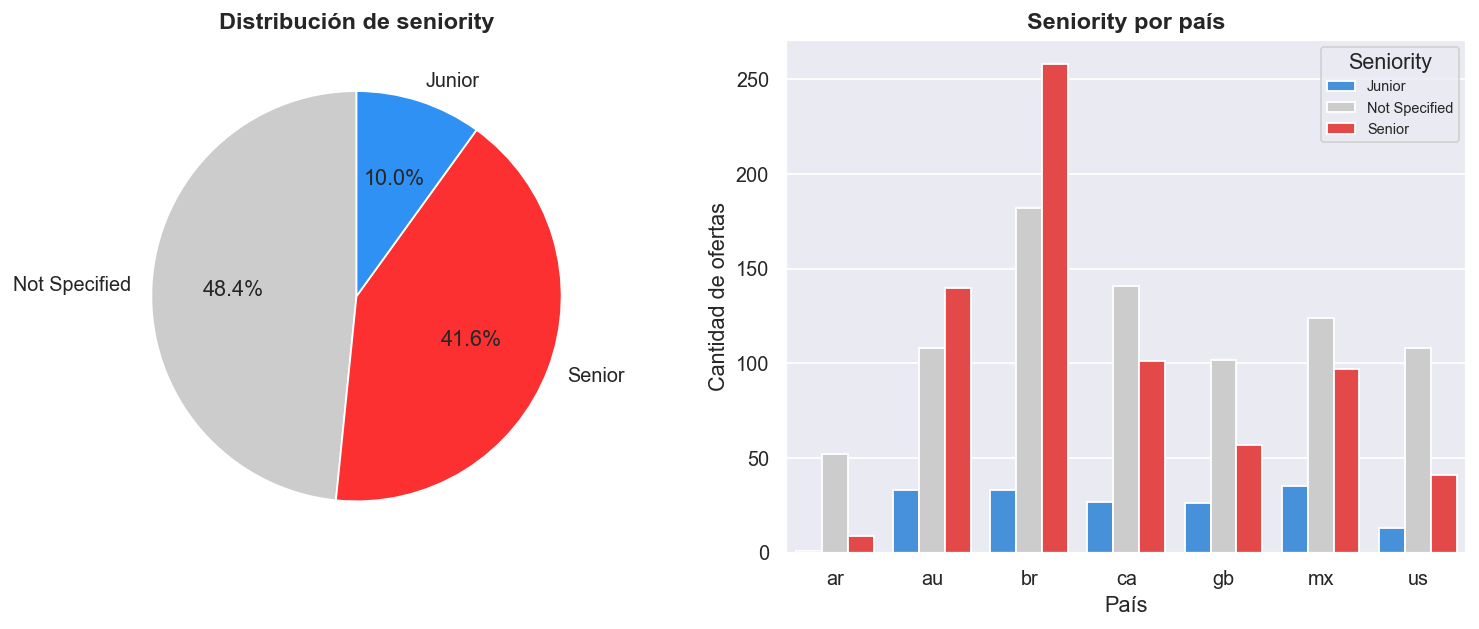

In [250]:
# Colores por categoría
COLORS = {
    "Junior": "#2F91F3",
    "Senior": "#FC3030",
    "Not Specified": "#CCCCCC",
}

# Creamos una figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Gráfico 1: Pie chart ---
axes[0].pie(
    seniority_counts["count"], # Tamaños de cada porción según la cantidad de ofertas en cada categoría
    labels=seniority_counts["seniority"], # Etiquetas con el nombre de cada categoría
    autopct="%1.1f%%",  # Muestra el porcentaje con un decimal dentro de cada porción
    colors=[COLORS.get(s) for s in seniority_counts["seniority"]], # Asigna colores según la categoría usando el diccionario COLORS
    startangle=90,  # Rota el gráfico
)
axes[0].set_title("Distribución de seniority")

# --- Gráfico 2: Barras ---
# Agrupamos por país y seniority para ver diferencias entre países
seniority_country = (
    df_clean.groupby(["country", "seniority"]) # Agrupa el DataFrame por las columnas "country" y "seniority"
    .size() # Cuenta cuántas filas hay en cada grupo
    .reset_index(name="count") # Convierte el resultado en un DataFrame con columnas "country", "seniority" y "count"
)

sns.barplot(
    data=seniority_country,
    x="country",
    y="count",
    hue="seniority",          # Separa las barras por categoría de seniority
    palette=COLORS,
    ax=axes[1],
)
axes[1].set_title("Seniority por país")
axes[1].set_xlabel("País")
axes[1].set_ylabel("Cantidad de ofertas")
axes[1].legend(title="Seniority", fontsize=8)

plt.tight_layout()
plt.savefig("../dashboard/assets/3_2_seniority.png", dpi=130)
plt.show()

## Insight 3.2 - Requisitos Junior

**Nota:** En el caso de **Argentina** al no contener descripciones en los registros, es de esperarse una mayor proporción de seniority no especificado ya que solo se puede extraer palabras clave de los títulos de las ofertas.

* El número que más me imapctó: solo el 10% de las ofertas son explícitamente Junior contra un 41.6% de Senior. Eso son 168 ofertas de 1688, solo 1 de cada 10.

* El 41.6% son senior, lo que significa que hay 4 veces más ofertas senior que Junior en el mercado. El 48% restante no especifica nivel, pero muchas de esas probablemente asumen experiencia previa.

**Conclusión:** el mercado no está esperando juniors con los brazos abiertos. La barrera de acceso para alguien que quiere iniciar como Analista de Datos es muy difícil.

---
### 3.3 - ¿Cuántos años de experiencia se solicita según seniority?

In [251]:
# Busca cosas como: "2 years", "3+ years", "2-4 years", "5 years of experience"
EXP_PATTERN = re.compile(
    r'\d+'        # uno o más dígitos (el número de años)
    r'\s*'        # espacios opcionales entre el número y el guión o signo +
    r'[-–]?'      # guión opcional (para rangos como "2-4")
    r'\s*'        # espacios opcionales después del guión
    r'\d*'        # segundo número opcional (el máximo del rango)
    r'\s*'        # espacios opcionales después del segundo número
    r'\+?'        # signo + opcional (para "2+")
    r'\s*'        # espacios opcionales después del signo +
    r'years?'     # "year" o "years" con "s" opcional
    r'(?:\s*of)?'         # "of" opcional (para frases como "5 years of experience")
    r'(?:\s*experience)?', # "experience" opcional (para frases como "5 years of experience")
    re.IGNORECASE # ignora mayúsculas/minúsculas
)

def extract_min_experience(text: str) -> str:
    """
    Extrae el mínimo de años de experiencia requerido del texto.
    Si hay varios números, toma el menor, asumiendo que es el requisito mínimo.
    
    Argumentos:
        Text: descripción de la oferta
        
    Returns:
        int o None: mínimo de años econtrado o None si no se encuentra nada."""
    # Verificamos que el texto sea una cadena antes de procesar
    if not isinstance(text, str):
        return None
    
    # Buscamos palabras clave relacionadas con experiencia para asegurarnos de que los números que encontremos estén en ese contexto
    matches = EXP_PATTERN.findall(text)
    if not matches:
        return None
    
    # Extraemos todos los números del texto
    mins = [int(m[0]) for m in matches if int(m[0]) <= 15] # Filtramos para quedarnos solo con números que tengan sentido como años de experiencia (0-15)
    return min(mins) if mins else None # Si encontramos números, devolvemos el menor, si no, devolvemos None
    
# Aplicamos la función de extracción de experiencia a la columna de descripción y guardamos los resultados en una nueva columna "exp_years"
df_with_desc["exp_years"] = df_with_desc["description"].apply(extract_min_experience)

# Contamos cuántas ofertas tienen un requisito de experiencia detectado
exp_found = df_with_desc["exp_years"].notna().sum()

print(f"Ofertas con experiencia extraíble: {exp_found} ({exp_found/len(df_with_desc)*100:.1f}%)")
print(df_with_desc["exp_years"].value_counts().sort_index())    

Ofertas con experiencia extraíble: 95 (5.8%)
exp_years
0.0     5
1.0    27
2.0    12
3.0    18
4.0    13
5.0    10
6.0     4
7.0     3
8.0     3
Name: count, dtype: int64


Solo se pudo extraer los años de experiencia de 95 ofertas. La limitante de Adzuna afecta mucho el análisis por desgracia.

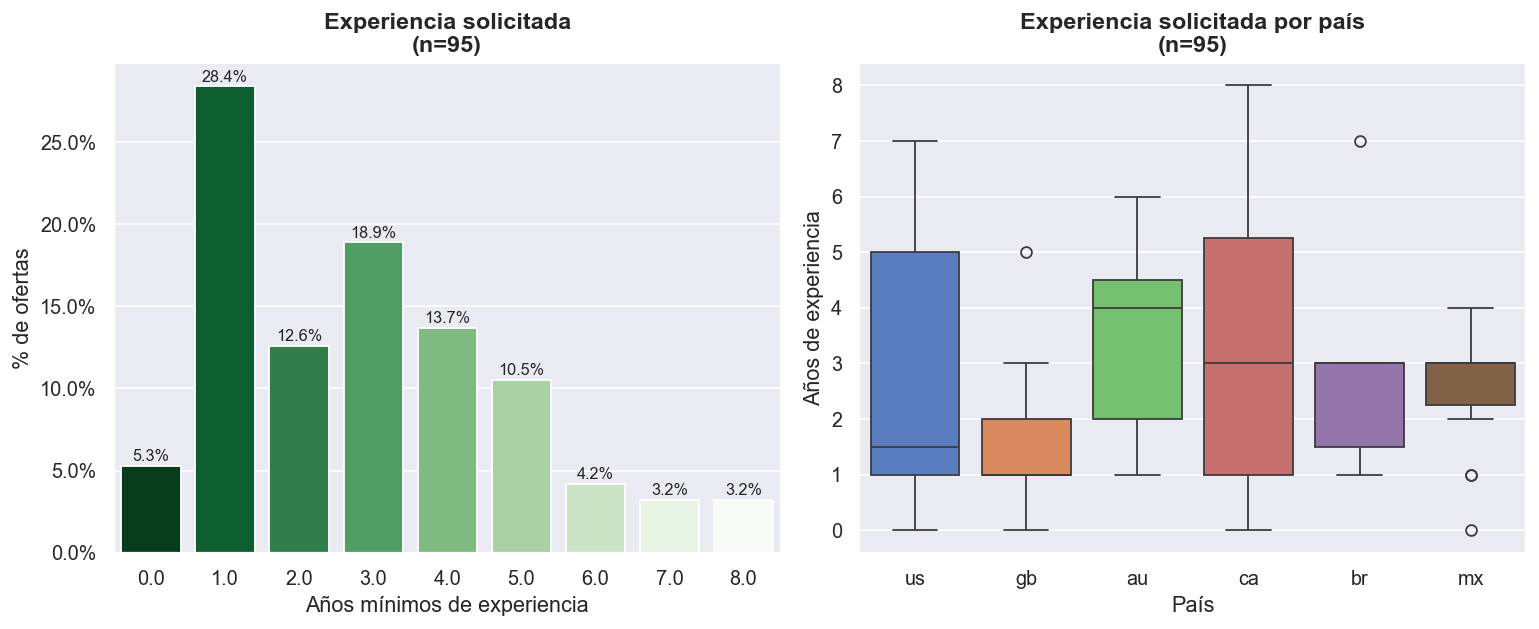

In [252]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Gráfico 1: Barras ---

# Filtramos solo las filas donde se pudo extraer experiencia
df_exp_plot = df_with_desc[df_with_desc["exp_years"].notna()]

# Calculamos el porcentaje de ofertas por cada año de experiencia
exp_pct = (
    df_exp_plot["exp_years"]
    .value_counts(normalize=True)   # normalize=True devuelve proporciones en lugar de conteos
    .mul(100)                       # multiplicamos por 100 para convertir a porcentaje
    .round(1)                       # redondeamos a 1 decimal
    .reset_index()                  # convierte el índice en una columna normal para poder graficar con seaborn
)
exp_pct.columns = ["exp_years", "pct"] # Renombramos las columnas para que tengan nombres descriptivos
exp_pct = exp_pct.sort_values("exp_years")  # ordenamos por años

sns.barplot(
    data=exp_pct,
    x="exp_years",
    y="pct",
    palette="Greens_r",
    hue="exp_years",
    legend=False,
    ax=axes[0],
    order=exp_pct["exp_years"],
)
axes[0].set_title(f"Experiencia solicitada\n(n={len(df_exp_plot)})")
axes[0].set_xlabel("Años mínimos de experiencia")
axes[0].set_ylabel("% de ofertas")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())

# Agregamos etiquetas con el porcentaje encima de cada barra
for bar, val in zip(axes[0].patches, exp_pct["pct"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,  # Centro horizontal de la barra
        bar.get_height() + 0.3,              # Justo encima de la barra
        f"{val}%",                           # Texto a mostrar
        ha="center",                         # Alineado al centro
        fontsize=9
    )

# --- Gráfico 2: Boxplot ---

sns.boxplot(
    data=df_exp_plot,
    x="country",       # Eje X: país
    y="exp_years",     # Eje Y: años de experiencia
    palette="muted",
    hue="country",
    ax=axes[1],
)
axes[1].set_title(f"Experiencia solicitada por país\n(n={len(df_exp_plot)})")
axes[1].set_xlabel("País")
axes[1].set_ylabel("Años de experiencia")

plt.tight_layout()
plt.savefig("../dashboard/assets/3_3_experiencia.png", dpi=130)
plt.show()

## Insight 3.3 - Experiencia solicitada

**Nota:** solo 95 de 1668 ofertas tienen dato de experiencia extraíble. El truncado a 500 caracteres limita mucho este análisis. Los años de experiencia suelen aparecer en el cuerpo de la oferta, no en la introducción. Misma razón por la que Argentina no fue incluído, ya que no son extraíbles las descripciones de computrabajo.

* Con esa limitación en mente, lo que muestran los datos disponibles es interesante: 1 año es el requisito más común (28.4% de los casos), seguido por 3 años (18.9%). La mayoría de las ofertas pide entre 1 y 3 años.

* El boxplot por país muestra medianas similares entre 2 y 4 años en todos los mercados. Australia y Canadá tienden a pedir algo más de experiencia que Reino Unido.

**Conclusión**: proyectos de portfolio, freelance o prácticas son prácticamente obligatorios para entrar. El mercado no contrata desde cero.

---
## 3.4 - Diferencias de skills técnicas por país

In [253]:
# Skills por país sobre ofertas con descripción disponible
for country, group in df_with_desc.groupby("country"):
    all_s = [s for skills in group["skills_found"] for s in skills] # Lista de todas las skills encontradas en el grupo de ofertas de ese país
    top = Counter(all_s).most_common(10) # Las 10 skills más comunes en ese país con sus conteos
    print(f"\nTop skills - {country.upper()}:")
    for skill, cnt in top:
        print(f"  {skill:<20} {cnt:>4} menciones")


Top skills - AU:
  sql                     9 menciones
  power bi                9 menciones
  azure                   6 menciones
  etl                     4 menciones
  machine learning        3 menciones
  tableau                 3 menciones
  excel                   2 menciones
  snowflake               1 menciones
  r                       1 menciones
  statistics              1 menciones

Top skills - BR:
  git                    21 menciones
  power bi               13 menciones
  sql                    10 menciones
  python                  9 menciones
  r                       7 menciones
  snowflake               4 menciones
  looker                  3 menciones
  azure                   3 menciones
  etl                     3 menciones
  excel                   2 menciones

Top skills - CA:
  sql                    11 menciones
  power bi                9 menciones
  r                       7 menciones
  excel                   6 menciones
  python                  6 mencio

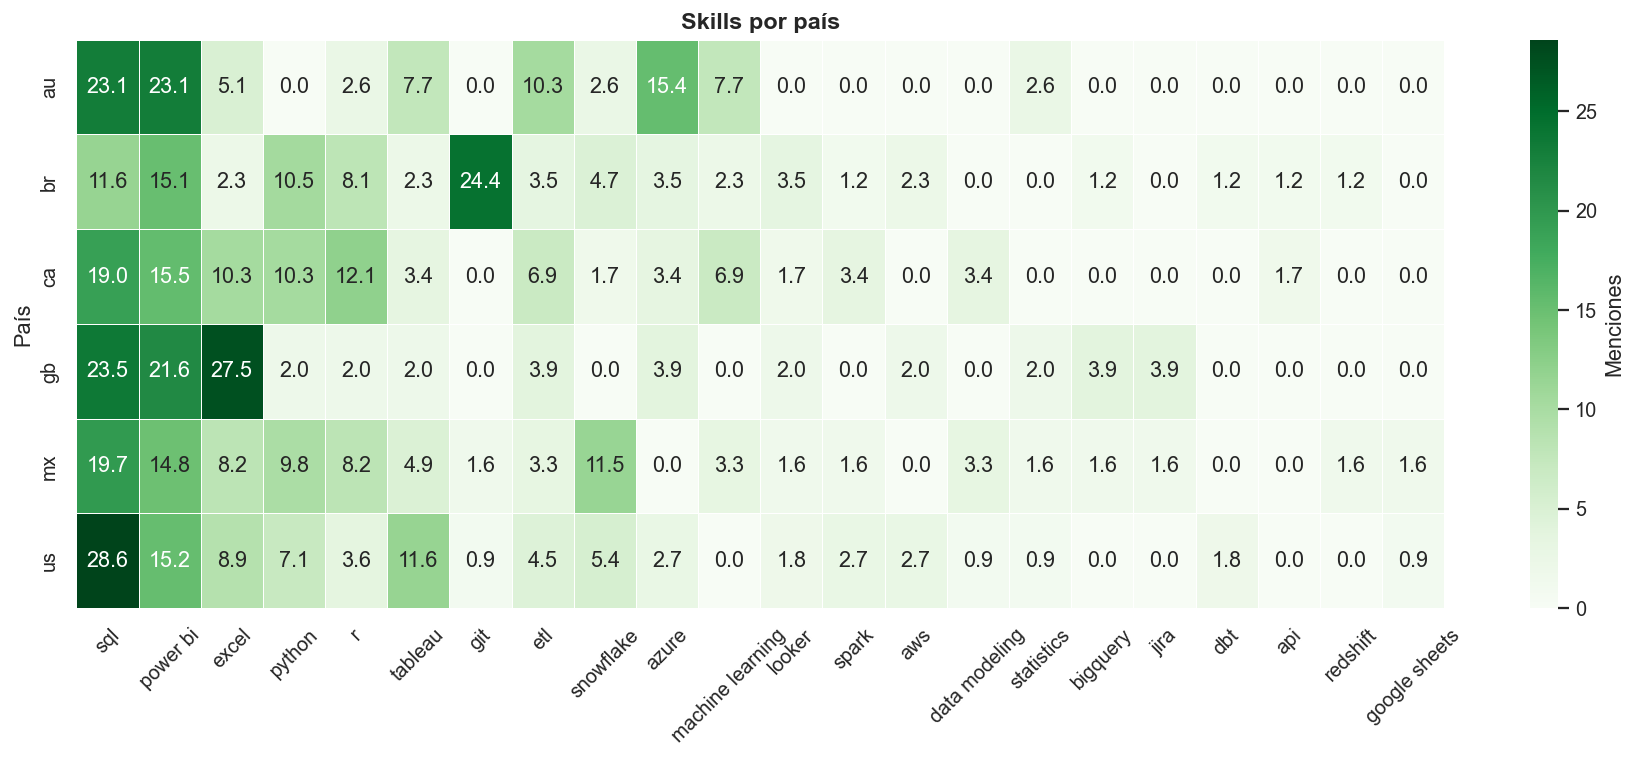

In [254]:
# Construimos una matriz: filas = países, columnas = skills

# Primero armamos un diccionario con los conteos por país
heatmap_dict = {}
# Iteramos por cada país y su grupo de ofertas, juntamos todas las skills encontradas en ese país y contamos cuántas veces aparece cada skill
for country, group in df_with_desc.groupby("country"):
    all_s = [s for skills in group["skills_found"] for s in skills]
    heatmap_dict[country] = Counter(all_s)

# Convertimos el diccionario en DataFrame
# Cada país es una fila, cada skill es una columna
# fillna(0) rellena con 0 donde un país no menciona una skill
df_heatmap = pd.DataFrame(heatmap_dict).T.fillna(0).astype(int)

# Nos quedamos solo con las skills que aparecen en al menos 2 países
# para evitar ruido de skills muy específicas de un solo mercado
df_heatmap = df_heatmap.loc[:, (df_heatmap > 0).sum() >= 2]

# Ordenamos las columnas por total de menciones de mayor a menor
df_heatmap = df_heatmap[df_heatmap.sum().sort_values(ascending=False).index]

# Dividimos cada fila por el total de menciones de ese país
# Multiplicamos por 100 y redondeamos para obtener porcentajes
df_heatmap_pct = df_heatmap.div(df_heatmap.sum(axis=1), axis=0).mul(100).round(1)

fig, ax = plt.subplots(figsize=(14, 6))

# --- Gráfico: Heatmap ---
sns.heatmap(
    df_heatmap_pct,
    annot=True,       # Muestra el número en cada celda
    fmt=".1f",          # Formato decimal con un dígito
    cmap="Greens",     # Paleta de azules: más intenso = más menciones
    linewidths=0.5,   # Líneas entre celdas para separar visualmente
    ax=ax,
    cbar_kws={"label": "Menciones"},
)
ax.set_title("Skills por país")
ax.set_xlabel("")
ax.set_ylabel("País")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../dashboard/assets/3_4_paises.png", dpi=130)
plt.show()

### Insight 3.4 - Diferencias de skills técnicas por país

SQL es la única skill verdaderamente universal, aparece primero todos los países, menos Reino Unido que lidera con Excel, siendo el más tradicional. Es el piso mínimo del rol en cualquier mercado.

**Conclusión:** SQL + Power BI cubre la mayoría de los mercados.Si apuntás a MX o AU, agregar cloud (Azure/Snowflake) al portfolio puede ser un diferenciador.

---
### 3.5 - Comparación salarial entre países

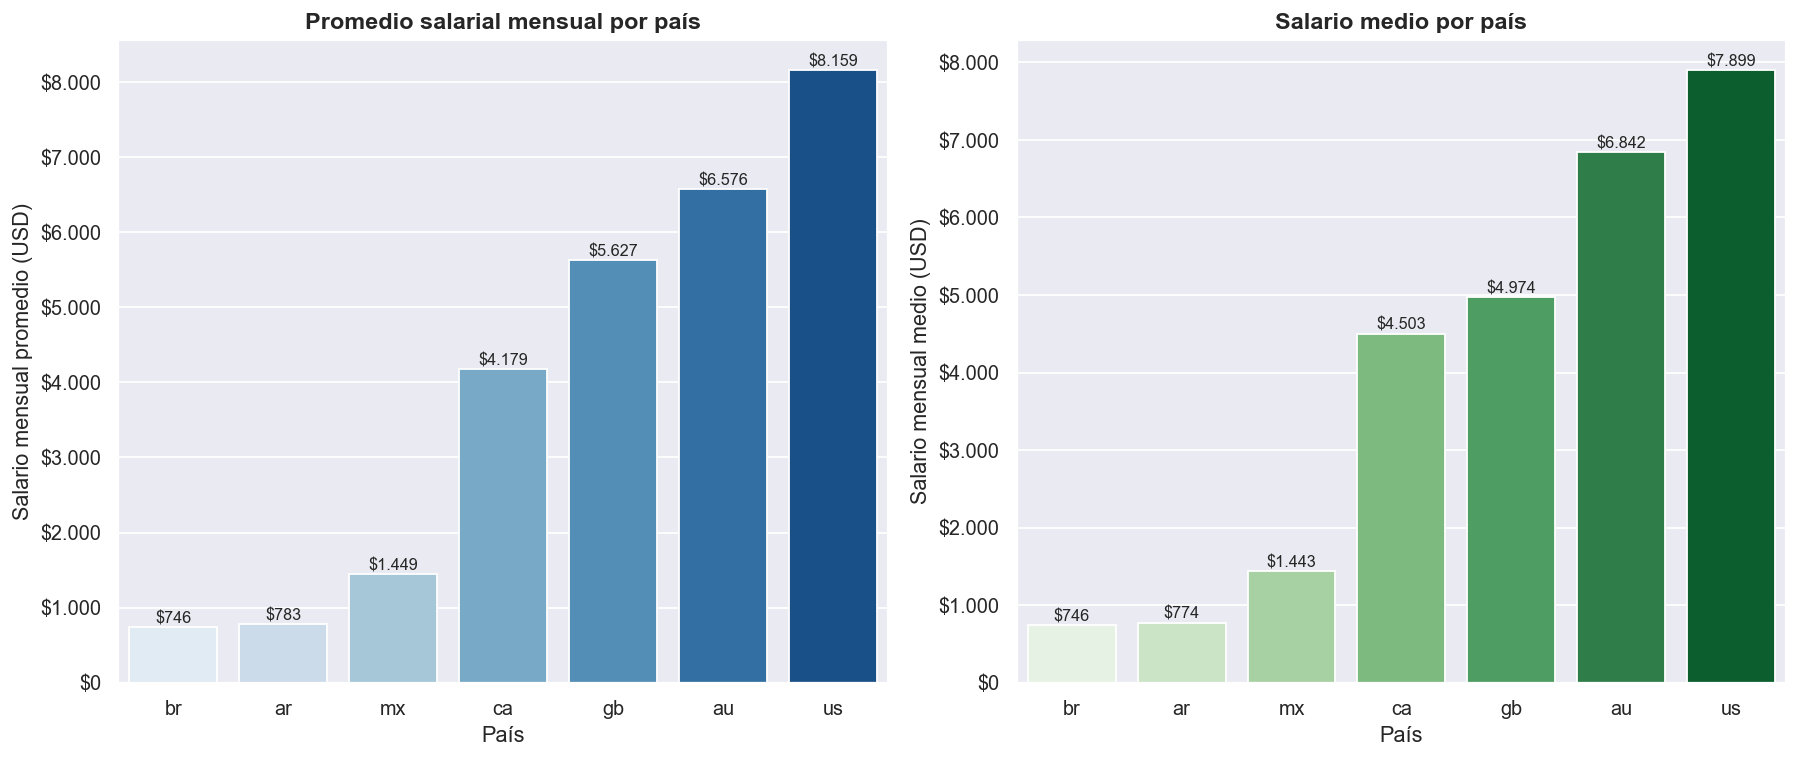

In [255]:
# Filtramos los nulos
df_salary = df_clean[df_clean["salary_monthly_usd"].notna()].copy()

salary_mean = (
    df_salary.groupby("country")["salary_monthly_usd"]
    .mean()
    .round(2)
    .reset_index()
    .sort_values("salary_monthly_usd", ascending=True)
)

salary_median = (
    df_salary.groupby("country")["salary_monthly_usd"]
    .median()
    .round(2)
    .reset_index()
    .sort_values("salary_monthly_usd", ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=salary_mean,
    x="country",
    y="salary_monthly_usd",
    palette="Blues",
    hue="country",
    ax=axes[0]
)
axes[0].set_title("Promedio salarial mensual por país")
axes[0].set_xlabel("País")
axes[0].set_ylabel("Salario mensual promedio (USD)")
# Formateamos el eje Y con símbolo de dólar y separador de miles
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}".replace(",", ".")))

# Etiquetas
for bar, val in zip(axes[0].patches, salary_mean["salary_monthly_usd"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"${val:,.0f}".replace(",", "."),
        ha="center",
        fontsize=9
    )

sns.barplot(
    data=salary_median,
    x="country",
    y="salary_monthly_usd",
    palette="Greens",
    hue="country",
    ax=axes[1]
)
axes[1].set_title("Salario medio por país")
axes[1].set_xlabel("País")
axes[1].set_ylabel("Salario mensual medio (USD)")
# Formateamos el eje Y con símbolo de dólar y separador de miles
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}".replace(",", ".")))

# Etiquetas
for bar, val in zip(axes[1].patches, salary_median["salary_monthly_usd"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"${val:,.0f}".replace(",", "."),
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("../dashboard/assets/3_5_salario_paises.png", dpi=130)
plt.show()

## Insight 3.5 - Comparación salarial por país

**Nota:** BR tiene solo 2 registros válidos. No tener tanto en cuenta.

* En un primer nivel, entre $6.500 y $8.500. El mercado más remunerado es claramente **Estados Unidos** con un promedio de $8.159 y una mediana de $7.899 mensuales. **Autralia** también se mantiene cerca con $6.842 de promedio.

* **Canadá y Gran Bretaña** En un segundo nivel entre $4.000 y $5.500 mensuales. En este caso, se puede ver que **Gran Bretaña** tiene la brecha más alta entre promedio y mediana.

* Por último, en un tercer nivel, **Brasil, Argentina y México** muestran la realidad de los mercados latinoamericanos: entre $750 y $1.450 mensuales en USD. La brecha con US es de casi 6 veces.

La conclusión práctica para alguien buscando trabajo remoto desde Argentina: apuntar al mercado US o AU puede significar multiplicar el salario por más de 5 veces.

---

# Conclusiones generales

Este análisis procesó 1688 ofertas reales de trabajo para Data Analys en 7 países, recolectadas mediante API y web scraping.

**Lo que aprendí del mercado:**

- **SQL es innegociable;** aparece en todos los países como la skill más demandada. Es el piso mínimo para entrar al rol.
- **Excel sigue siendo relevante;** el mercado no migró completamente a herramientas modernas.
- **Python es un diferenciador, no un requisito universal;** aparece en el 14% de las ofertas con skills detectables. Suma, pero no es obligatorio en todos los mercados.
- **Solo el 10% de las ofertas son explícitamente junior;** el mercado es duro para quienes recién empiezan. Un portfolio sólido es casi obligatorio.
- **La experiencia pedida ronda entre 1 y 3 años;** incluso para posiciones de entrada.
- **La brecha salarial entre mercados es enorme;** apuntar a US o AU desde Argentina puede significar multiplicar el salario por más de 5 veces.

**Lo que aprendí técnicamente en este proyecto:**

- Consumo de APIs REST con autenticación
- Web scraping con BeautifulSoup
- NLP con búsqueda por lista predefinida y regex
- Documentación de limitaciones de datos reales

**Limitación principal:** el truncado a 500 caracteres de la API gratuita de Adzuna afecta mi detección de skills, lo que me obliga a trabajar con muestras pequeñas.

> *Datos recolectados: mayo - junio 2026 | Fuentes: Adzuna API, Computrabajo*

---
## Sección 4: Exportación de datos

In [256]:
import os
os.makedirs("../data/processed", exist_ok=True)
print("Carpeta lista")

Carpeta lista


In [257]:
# ============================================================
# SECCIÓN 4 — EXPORTACIÓN PARA POWER BI
# ============================================================

# --- 4.1 Skills agregadas (Sección 3.1) ---
# df_skills ya tiene las columnas skill, count, pct_total, pct_con_skills
df_skills.to_csv("../data/processed/1_skills_aggregated.csv", index=False)
print("✓ 1_skills_aggregated.csv")

# --- 4.2 Seniority (Sección 3.2) ---
# seniority_counts ya tiene seniority, count, pct
seniority_counts.to_csv("../data/processed/2_seniority_distribution.csv", index=False)
print("✓ 2_seniority_distribution.csv")

# --- 4.3 Experiencia (Sección 3.3) ---
# Exportamos la distribución de años de experiencia
exp_export = (
    df_with_desc["exp_years"]
    .dropna()
    .value_counts()
    .sort_index()
    .reset_index()
)
exp_export.columns = ["exp_years", "count"]
exp_export["pct"] = (exp_export["count"] / exp_export["count"].sum() * 100).round(1)
exp_export.to_csv("../data/processed/3_experience_distribution.csv", index=False)
print("✓ 3_experience_distribution.csv")

# --- 4.4 Skills por país (Sección 3.4) ---
# Convertimos el heatmap a formato largo para Power BI
# Power BI trabaja mejor con filas que con matrices
df_skills_country = df_heatmap.reset_index()
df_skills_country = df_skills_country.melt(
    id_vars="index",        # columna que identifica el país
    var_name="skill",       # nombre de la columna de skills
    value_name="count"      # nombre de la columna de conteos
)
df_skills_country.columns = ["country", "skill", "count"]

# Agregamos el porcentaje por país
df_skills_country["pct"] = (
    df_skills_country.groupby("country")["count"]
    .transform(lambda x: (x / x.sum() * 100).round(1))
)

# Eliminamos filas con 0 menciones — no aportan en Power BI
df_skills_country = df_skills_country[df_skills_country["count"] > 0]
df_skills_country.to_csv("../data/processed/4_skills_by_country.csv", index=False)
print("✓ 4_skills_by_country.csv")

# --- 4.5 Salario por país (Sección 3.5) ---
salary_export = (
    df_clean[df_clean["salary_monthly_usd"].notna()]
    .groupby("country")["salary_monthly_usd"]
    .agg(["count", "mean", "median"])
    .round(2)
    .reset_index()
)
salary_export.columns = ["country", "count", "mean_usd", "median_usd"]
salary_export.to_csv("../data/processed/5_salary_by_country.csv", index=False)
print("✓ 5_salary_by_country.csv")

# --- 4.6 Dataset completo limpio ---
# Exportamos df_clean completo para análisis ad-hoc en Power BI
df_clean.to_csv("../data/processed/6_jobs_clean.csv", index=False)
print("✓ 6_jobs_clean.csv")

print("\nExportación completa. Archivos en data/processed/")

✓ 1_skills_aggregated.csv
✓ 2_seniority_distribution.csv
✓ 3_experience_distribution.csv
✓ 4_skills_by_country.csv
✓ 5_salary_by_country.csv
✓ 6_jobs_clean.csv

Exportación completa. Archivos en data/processed/
